In [1]:
from config_path import add_to_sys_path
add_to_sys_path()  # Call the function to add path

import numpy as np
from sympy.physics.wigner import wigner_3j,wigner_6j
import sympy as sy
from numpy import linalg as LA
from IPython.display import Latex,display
import matplotlib.pyplot as plt
from matplotlib import colors
%matplotlib inline
import seaborn as sns
sns.set()
sns.set_palette('bright')
from Energy_Levels import MoleculeLevels
from Energy_Levels import branching_ratios, Calculate_TDMs,Calculate_TDM_evecs
from functools import partial
np.set_printoptions(precision=7, suppress=True)
# from tabulate import tabulate
from matplotlib.collections import LineCollection
from matplotlib.colors import TwoSlopeNorm

Added /Users/arianjadbabaie/Library/CloudStorage/GoogleDrive-arianjad@mit.edu/Shared drives/EMA-data-server/RaX/Personal/ArianJadbabaie/Code/Molecule-Structure/Source Code to sys.path


In [2]:
A0 = MoleculeLevels.initialize_state(
    molecule_name = 'RaF', 
        # Used to look up constants in central database if params = None
    elec_state = 'A',
        # Electronic state label, e.g. 'X', 'A', etc
    vib_state = 0,
        # Vibrational state label, can be either integer or '000', '010', etc.
    N_list = np.arange(1,4,1), 
        # List of rotational states to consider. 
    fermion_or_boson = 'fermion', 
        # Is the total F integer or half-integer?
    M_sublevels = 'custom', 
        # Options are 'all' (default), 'none' 'pos', or 'custom'. Specifying 'custom' means the input to kwarg M_list is used
    M_list = [1/2],
    I_nuclei = [1/2,1/2], 
        # List of nuclear spins in the molecule. Order goes [Metal, Ligand]
    isotope = 225, 
        # Atomic mass, optional but makes plots nicer, functionally just used for backwards compatability for YbOH
    round=8, 
        # Round all numerical values to this many digits
    params = None,
        # If None, use database to look up effective Hamiltonian constants. Otherwise, input a dictionary of constants to override database values.
    P_values = [1/2,3/2],
        # List of projection quantum numbers of J (aka Omega) to consider (i.e. [1/2] or [1/2, 3/2] for a Pi_1/2 state)
)

In [44]:
sns.set_style('ticks')

In [13]:
A0.update_params({'dYb':-A0.parameters['dYb'],'h1/2Yb':0},recompute=True)

In [14]:
print(A0.parameters)

{'mu_B': 1.399624494, 'g_S': 2.0023, 'g_L': 1, '2_e0c': 75346062800.0, 'mu_N': 0.000762259323, 'c': 29979.2458, 'Be': 5729.038394188824, 'ASO': 40471981.83, 'h1/2Yb': 0, 'dYb': 2278.4226808, 'h1/2H': 9.5, 'aH': 9.5, 'bFH': 0, 'cH': 0, 'dH': -9, 'p+2q': -12318.466403163298, 'q': 0, 'e2Qq0': 0, 'D': 0.004197094412, 'p2q_D': 0.005696056702, 'g_lp': -1.075091575091575, 'muE': 0.503412, 'Origin': 13284.618984816376}


d = 2278.4226808


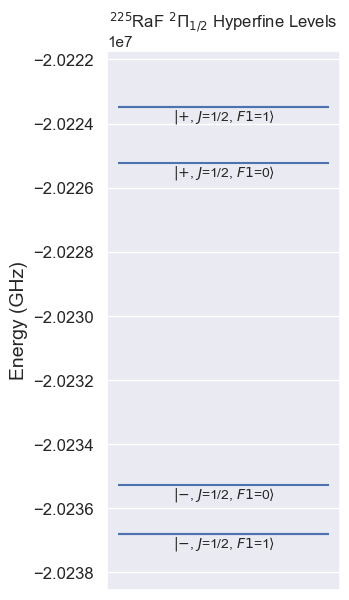

In [15]:
ASO = 40471000
print('d =',A0.parameters['dYb'])
A0.display_levels(0,1e-8,pattern_q='J',
                  idx=A0.select_q({'J':[0.5],'P':[1/2]}),label=True,
                  label_q=['J','F1'],parity=True,alt_label=False,figsize=(3,7),deltaE_label=500, )
plt.xlabel('')
plt.minorticks_on()
# actual_ticks = np.arange(-7e3,-3e3+1e3,1e3)-ASO/2+16e3
# plt.yticks(actual_ticks,labels=np.arange(0,5,1))
plt.xticks([])
# plt.ylim(-10e3,90e3)
plt.ylabel('Energy (GHz)')
plt.title(r'$^{225}$RaF ${}^2\Pi_{1/2}$ Hyperfine Levels',fontsize=12)
plt.show()

d = 2278.4226808


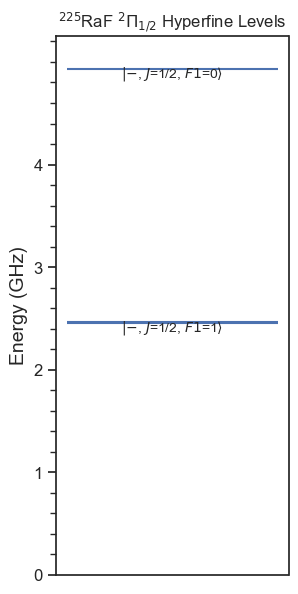

In [7]:
ASO = 40471000
print('d =',A0.parameters['dYb'])
A0.display_levels(0,1e-8,pattern_q='J',
                  idx=A0.select_q({'J':[0.5],'P':[1/2]},parity='-'),label=True,
                  label_q=['J','F1'],parity=True,alt_label=False,figsize=(3,7),deltaE_label=500, )
plt.xlabel('')
plt.minorticks_on()
actual_ticks = np.arange(-20e3,-16e3+1e3,1e3)-ASO/2+16e3
plt.yticks(actual_ticks,labels=np.arange(0,5,1))
plt.xticks([])
# plt.ylim(-10e3,90e3)
plt.ylabel('Energy (GHz)')
plt.title(r'$^{225}$RaF ${}^2\Pi_{1/2}$ Hyperfine Levels',fontsize=12)
plt.show()

In [37]:
jidx = A0.select_q({'J':[0.5],'P':[1/2]})
for j in jidx:
    print((A0.evals0[j]-A0.evals0[0])/(29979.2458))
    display(Latex(A0.gen_state_str(j,single=True,parity=True,show_coeff=False)))

0.0


<IPython.core.display.Latex object>

0.00020704525024526664


<IPython.core.display.Latex object>

0.08259965007565344


...

<IPython.core.display.Latex object>

0.4699814637842213


<IPython.core.display.Latex object>

0.47031580676153545


<IPython.core.display.Latex object>

In [22]:
vals_cm = np.array([
    13284.68975943310,
    13284.278828886700,
    15351.878828886700,
    15352.289759433100,
    13285.468512058900,
    13284.646652106200,
    15352.246652106200,
    15353.068512058900,
    13286.629449893200,
    13285.396662814200,
    15352.99666281420,
    15354.229449893200
])


In [23]:
vals_cm = vals_cm[vals_cm<14000]
vals_cm-= vals_cm.min()
vals_cm = np.array(sorted(vals_cm.tolist()))

In [24]:
vals = vals_cm*29979.2458

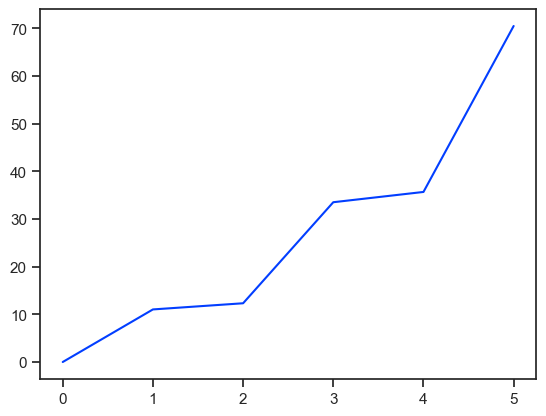

In [25]:
plt.figure()
plt.plot(vals/1e3)
plt.show()

In [23]:
A0.eigensystem(0,1e-8)
idx_list = A0.select_q({'J':[0.5,1.5],'P':[1/2]},parity='+')

In [17]:
for i in idx_list:
    print(f'State {i}', f'Energy = {(A0.evals0[i]+ASO/2)/1e3:.6f} GHz')
    state_str_aBJ = A0.gen_state_str(i, parity=True,label_q=['K','J','F1','F'],round=6,thresh=0.0001)
    # state_str_bBJ = A0.gen_state_str(i, parity=True,basis = 'bBJ',label_q=['N','J','F1','F'], round=6,thresh=0.0001)
    state_str_bBS = A0.gen_state_str(i, parity=True,basis='bBS',label_q=['K','G','N','F1','F'],round=6,thresh=0.0001)
    print('Case A')
    display(Latex(state_str_aBJ))
    # print('Case B_bJ')
    # display(Latex(state_str_bBJ))
    print('Case B_bS')
    display(Latex(state_str_bBS))

State 3 Energy = 9.564575 GHz
Case A


/Users/arianjadbabaie/Library/CloudStorage/GoogleDrive-arianjad@mit.edu/Shared drives/EMA-data-server/RaX/Personal/ArianJadbabaie/Code/Molecule-Structure/Source Code/Energy_Levels.py:913: RuntimeWarning: invalid value encountered in divide
  converted_evecs[i]/=evec@evec


<IPython.core.display.Latex object>

Case B_bS


<IPython.core.display.Latex object>

...

<IPython.core.display.Latex object>

State 9 Energy = 13.249568 GHz
Case A


<IPython.core.display.Latex object>

Case B_bS


<IPython.core.display.Latex object>

In [21]:
X0 = MoleculeLevels.initialize_state(
    molecule_name = 'RaF', 
        # Used to look up constants in central database if params = None
    elec_state = 'X',
        # Electronic state label, e.g. 'X', 'A', etc
    vib_state = 0,
        # Vibrational state label, can be either integer or '000', '010', etc.
    N_list = np.arange(0,4,1), 
        # List of rotational states to consider. 
    fermion_or_boson = 'fermion', 
        # Is the total F integer or half-integer?
    M_sublevels = 'none', 
        # Options are 'all' (default), 'none' 'pos', or 'custom'. Specifying 'custom' means the input to kwarg M_list is used
    M_list = [1/2],
    I_nuclei = [1/2,1/2], 
        # List of nuclear spins in the molecule. Order goes [Metal, Ligand]
    isotope = 225, 
        # Atomic mass, optional but makes plots nicer, functionally just used for backwards compatability for YbOH
    round=8, 
        # Round all numerical values to this many digits
    params = None,
        # If None, use database to look up effective Hamiltonian constants. Otherwise, input a dictionary of constants to override database values.
    P_values = [1/2],
        # List of projection quantum numbers of J (aka Omega) to consider (i.e. [1/2] or [1/2, 3/2] for a Pi_1/2 state)
)

Cannot construct decoupled basis without M values


In [22]:
gidx = X0.select_q({'N':[1]},parity='-')

In [11]:
for i in gidx:
    print(f'State {i}', f'Energy = {X0.evals0[i]/1e3:.6f} GHz')
    state_str_aBJ = X0.gen_state_str(i, parity=True,basis='aBJ',label_q=['J','F1','F'],round=6,thresh=0.0001)
    # state_str_bBJ = A0.gen_state_str(i, parity=True,basis = 'bBJ',label_q=['N','J','F1','F'], round=6,thresh=0.0001)
    state_str_bBS = X0.gen_state_str(i, parity=True,basis='bBS',label_q=['G','N','F1','F'],round=6,thresh=0.0001)
    print('Case A')
    display(Latex(state_str_aBJ))
    # print('Case B_bJ')
    # display(Latex(state_str_bBJ))
    print('Case B_bS')
    display(Latex(state_str_bBS))

State 2 Energy = 7.126468 GHz
Case A


<IPython.core.display.Latex object>

Case B_bS


<IPython.core.display.Latex object>

State 3 Energy = 7.166448 GHz
Case A


...

<IPython.core.display.Latex object>

State 9 Energy = 23.940563 GHz
Case A


<IPython.core.display.Latex object>

Case B_bS


<IPython.core.display.Latex object>

In [15]:
for i in X0.select_q({'N':[3],'G':[1]}):
    print(f'State {i}', f'Energy = {X0.evals0[i]/1e3:.6f} GHz')
    state_str_aBJ = X0.gen_state_str(i, parity=True,basis='aBJ',label_q=['J','F1','F'],round=6,thresh=0.0001)
    # state_str_bBJ = A0.gen_state_str(i, parity=True,basis = 'bBJ',label_q=['N','J','F1','F'], round=6,thresh=0.0001)
    state_str_bBS = X0.gen_state_str(i, parity=True,basis='bBS',label_q=['G','N','F1','F'],round=6,thresh=0.0001)
    print('Case A')
    display(Latex(state_str_aBJ))
    # print('Case B_bJ')
    # display(Latex(state_str_bBJ))
    print('Case B_bS')
    display(Latex(state_str_bBS))

State 18 Energy = 64.634432 GHz
Case A


<IPython.core.display.Latex object>

Case B_bS


<IPython.core.display.Latex object>

State 19 Energy = 64.694946 GHz
Case A


...

<IPython.core.display.Latex object>

State 23 Energy = 65.253273 GHz
Case A


<IPython.core.display.Latex object>

Case B_bS


<IPython.core.display.Latex object>

In [24]:
sns.set_style('ticks')

In [17]:
Gamma

28571.428571428572

R226 = 1587.3015873015875
R225 = 907.02947845805


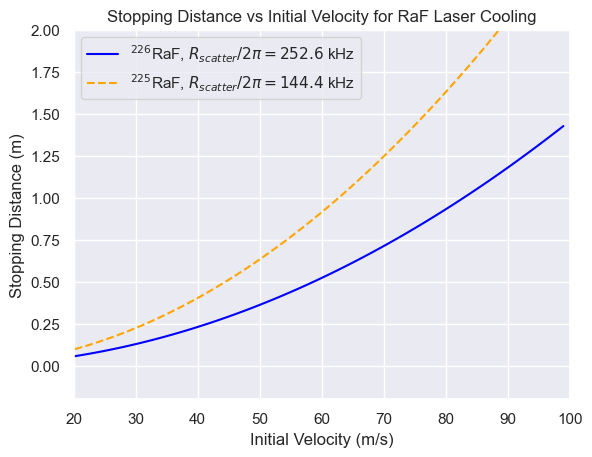

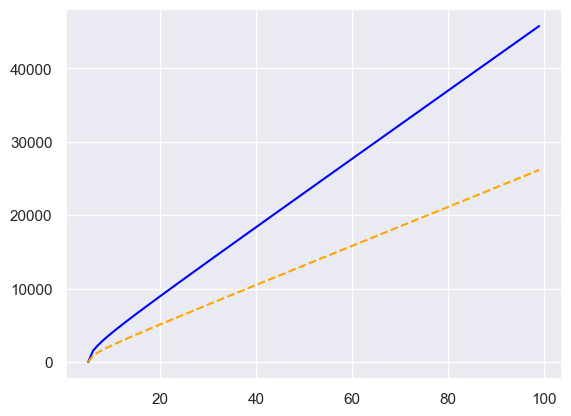

In [36]:
plt.figure()
vi = 5
v = np.arange(vi,100,1)
x=v
Gamma = 1/(35e-6) # in kHz*2pi
Gamma_max_226 = Gamma * 1/4
reduction_factor = 4.5 # See this paper: https://arxiv.org/pdf/2508.15994
Gamma_eff_226 = Gamma_max_226/reduction_factor
R226 = Gamma_eff_226
R225 = R226/1.75
print('R226 =',R226)
print('R225 =',R225)
conversion = 1
y226 = (x**2-vi**2)/(2*R226*2.16) * conversion
y225 = (x**2-vi**2)/(2*R225*2.16) * conversion
plt.plot(x,y226,# in kHz*2pi
pltma_max_26 = Gmma * 1/4
plt.legend(loc='best')
plt.n_factor= 4.5 # See this paper: https://arxiv.org/pdf/2508.15994
plt.f_226 = Gama_max_226/reduction_factor
plt.minorticks_on()
plt.amma_eff_226
plt.226/1.75
plt.226 =',R226)
# plt.axvline(x=50,r='orank',linestyle=':',estyle='--')
# plt.axhline(y=3.5,k',:',7
# plt.axhline(y=3.5,color='k',linestyle=':',alpha=0.75)
t_226 = np.sqrt(2*y226/(R226*2.16)) #sec
t_225 = np.sqrt(2*y225/(R225*2.16)) #sec
n_226 = t_226*1e3*R226
n_225 = t_226*1e3*R225
plt.figure()
plt.plot(x,n_226,label=rf'$^{{226}}$RaF, $R_{{scatter}}/2\pi = {{{np.round(R226/(2*np.pi),1)}}}$ kHz',color='blue')
plt.plot(x,n_225,label=rf'$^{{225}}$RaF, $R_{{scatter}}/2\pi = {{{np.round(R225/(2*np.pi),1)}}}$ kHz',color='orange',linestyle='--')
plt.show()

In [64]:
sns.set_style('ticks')

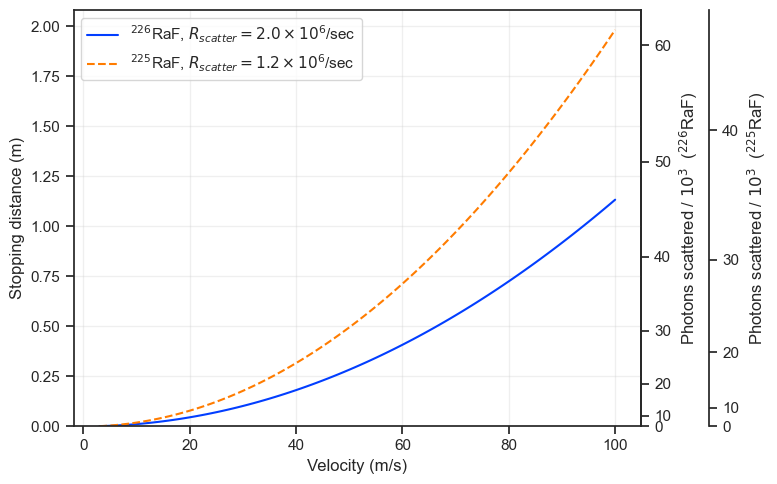

In [76]:
# Retry with robust mapping (clip negatives to zero to avoid sqrt of tiny negative due to FP)
import numpy as np
import matplotlib.pyplot as plt

# Demo data (replace with your variables in your script)
vi = 3
x = np.arange(vi, 101, 1)
Gamma = 1/(35e-6)
Gamma_max_226 = Gamma * 1/4
reduction_factor = 3.5
R226 = Gamma_max_226/reduction_factor
R225 = R226/1.75
recoil_v = 2.16

y226 = (x**2 - vi**2) / (2 * R226 * recoil_v)
y225 = (x**2 - vi**2) / (2 * R225 * recoil_v)

def make_forward_inverse(R, recoil_v):
    def forward(y):
        y = np.asarray(y)
        y = np.clip(y, 0, None)  # guard tiny negatives
        return np.sqrt(2.0 * R * y / recoil_v)
    def inverse(n_thousands):
        n_thousands = np.asarray(n_thousands)
        n_thousands = np.clip(n_thousands, 0, None)
        return (n_thousands**2) * (recoil_v / (2.0 * R))
    return forward, inverse

f226, finv226 = make_forward_inverse(R226, recoil_v)
f225, finv225 = make_forward_inverse(R225, recoil_v)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(x, y226, linestyle='-', label=rf'$^{{226}}$RaF, $R_{{scatter}} = {{{np.round(R226/1e3,1)}}}\times 10^6$/sec')
ax.plot(x, y225, linestyle='--', label=rf'$^{{225}}$RaF, $R_{{scatter}} = {{{np.round(R225/1e3,1)}}}\times 10^6$/sec')
ax.set_xlabel("Velocity (m/s)")
ax.set_ylabel("Stopping distance (m)")
ax.grid(True, which="both", alpha=0.3)
ax.set_ylim(bottom=0)

sec226 = ax.secondary_yaxis('right', functions=(f226, finv226))
sec226.set_ylabel(r"Photons scattered / $10^3$  ($^{226}$RaF)")
sec225 = ax.secondary_yaxis(1.12, functions=(f225, finv225))
sec225.set_ylabel(r"Photons scattered / $10^3$  ($^{225}$RaF)")

ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


In [71]:
import numpy as np
import matplotlib.pyplot as plt

# --- assumes you already have: x, y226, y225, n226, n225 ---
n225 = n_225
n226 = n_226

# --- assumes you already computed: x, y226, y225, n226, n225 ---

def make_nonlinear_mapping(dist, photons_scaled):
    """Build forward/inverse mappings for secondary_yaxis.
    dist ↔ photons_scaled must be monotonic in dist; this enforces it robustly."""
    dist = np.asarray(dist).ravel()
    photons_scaled = np.asarray(photons_scaled).ravel()

    # 1) keep only finite & matching indices
    m = np.isfinite(dist) & np.isfinite(photons_scaled)
    d = dist[m]
    n = photons_scaled[m]

    # 2) sort by distance
    order = np.argsort(d)
    d = d[order]
    n = n[order]

    # 3) ensure strictly increasing x for np.interp by dropping duplicate d's
    #    (take the first occurrence)
    uniq_d, uniq_idx = np.unique(d, return_index=True)
    d = d[uniq_idx]
    n = n[uniq_idx]

    # 4) forward/inverse maps
    def d_to_n(v):  # distance -> photons_scaled
        return np.interp(v, d, n)
    def n_to_d(v):  # photons_scaled -> distance
        return np.interp(v, n, d)

    # also return bounds to keep ticks within valid range
    return d_to_n, n_to_d, (d.min(), d.max()), (n.min(), n.max())

# scale photons to /1e3 for label compactness
n226k = np.asarray(n226) / 1e3
n225k = np.asarray(n225) / 1e3

# build mappings (NONLINEAR) from your arrays
f226, finv226, dlim226, nlim226 = make_nonlinear_mapping(y226, n226k)
f225, finv225, dlim225, nlim225 = make_nonlinear_mapping(y225, n225k)

# --- plot ---
fig, ax = plt.subplots(figsize=(8, 5))

# left y: stopping distance (ONLY TWO LINES)
line226, = ax.plot(x, y226, label=r'$^{226}$RaF')
line225, = ax.plot(x, y225, '--', label=r'$^{225}$RaF')
ax.set_xlabel('Velocity (m/s)')
ax.set_ylabel('Stopping distance (m)')
ax.grid(True, which='both', alpha=0.3)
ax.legend(loc='upper left')

# right y (1): photons for 226, NONLINEAR mapping of left axis
sec226 = ax.secondary_yaxis('right', functions=(f226, finv226))
sec226.set_ylabel(r'Photons / $10^3$ ($^{226}$RaF)')

# right y (2): photons for 225, offset and NONLINEAR mapping
sec225 = ax.secondary_yaxis(1.10, functions=(f225, finv225))
sec225.set_ylabel(r'Photons / $10^3$ ($^{225}$RaF)')

# optional: color-code spines/ticks to match the isotope line colors
c226 = line226.get_color()
c225 = line225.get_color()
sec226.tick_params(axis='y', colors=c226)
sec226.spines['right'].set_edgecolor(c226)
sec225.tick_params(axis='y', colors=c225)
sec225.spines['right'].set_edgecolor(c225)

# keep all axes within valid mapping ranges
ax.set_ylim(min(dlim226[0], dlim225[0]), max(dlim226[1], dlim225[1]))

plt.tight_layout()
plt.show()



ValueError: operands could not be broadcast together with shapes (96,) (95,) 

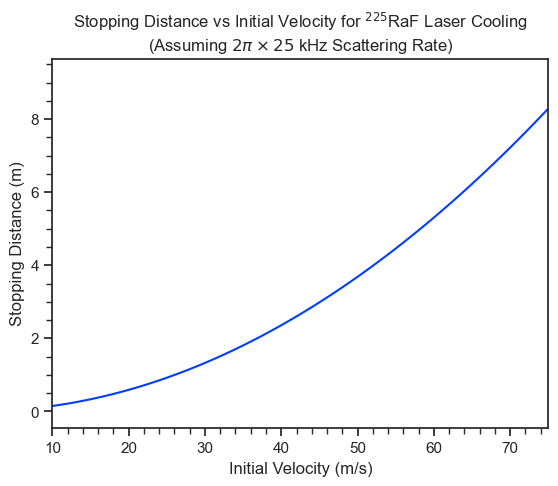

In [36]:
x = np.arange(0,80)
R = 2*np.pi * 25e3
conversion = 1000
y = x**2/(2*R*2.16) * conversion
plt.plot(x,y)
plt.xlim(10,75)
plt.minorticks_on()
plt.xlabel('Initial Velocity (m/s)')
plt.ylabel('Stopping Distance (m)')
plt.title(r'Stopping Distance vs Initial Velocity for $^{225}$RaF Laser Cooling'+'\n'+ r'(Assuming $2\pi\times 25$ kHz Scattering Rate)')
plt.show()

In [1]:
from config_path import add_to_sys_path
add_to_sys_path()  # Call the function to add path

import numpy as np
from sympy.physics.wigner import wigner_3j,wigner_6j
import sympy as sy
from numpy import linalg as LA
from IPython.display import Latex,display
import matplotlib.pyplot as plt
from matplotlib import colors
%matplotlib inline
import seaborn as sns
sns.set()
sns.set_palette('bright')
from Energy_Levels import MoleculeLevels
from Energy_Levels import branching_ratios, Calculate_TDMs,Calculate_TDM_evecs
from functools import partial
np.set_printoptions(precision=7, suppress=True)
# from tabulate import tabulate
from matplotlib.collections import LineCollection
from matplotlib.colors import TwoSlopeNorm

Added /Users/arianjadbabaie/Library/CloudStorage/GoogleDrive-arianjad@mit.edu/Shared drives/EMA-data-server/RaX/Personal/ArianJadbabaie/Code/Molecule-Structure/Source Code to sys.path


In [2]:
A0 = MoleculeLevels.initialize_state(
    molecule_name = 'RaF', 
        # Used to look up constants in central database if params = None
    elec_state = 'A',
        # Electronic state label, e.g. 'X', 'A', etc
    vib_state = 0,
        # Vibrational state label, can be either integer or '000', '010', etc.
    N_list = np.arange(1,4,1), 
        # List of rotational states to consider. 
    fermion_or_boson = 'fermion', 
        # Is the total F integer or half-integer?
    M_sublevels = 'none', 
        # Options are 'all' (default), 'none' 'pos', or 'custom'. Specifying 'custom' means the input to kwarg M_list is used
    M_list = [1/2],
    I_nuclei = [1/2,1/2], 
        # List of nuclear spins in the molecule. Order goes [Metal, Ligand]
    isotope = 225, 
        # Atomic mass, optional but makes plots nicer, functionally just used for backwards compatability for YbOH
    round=8, 
        # Round all numerical values to this many digits
    params = None,
        # If None, use database to look up effective Hamiltonian constants. Otherwise, input a dictionary of constants to override database values.
    P_values = [1/2,3/2],
        # List of projection quantum numbers of J (aka Omega) to consider (i.e. [1/2] or [1/2, 3/2] for a Pi_1/2 state)
)

X0 = MoleculeLevels.initialize_state(
    molecule_name = 'RaF', 
        # Used to look up constants in central database if params = None
    elec_state = 'X',
        # Electronic state label, e.g. 'X', 'A', etc
    vib_state = 0,
        # Vibrational state label, can be either integer or '000', '010', etc.
    N_list = np.arange(0,4,1), 
        # List of rotational states to consider. 
    fermion_or_boson = 'fermion', 
        # Is the total F integer or half-integer?
    M_sublevels = 'none', 
        # Options are 'all' (default), 'none' 'pos', or 'custom'. Specifying 'custom' means the input to kwarg M_list is used
    M_list = [1/2],
    I_nuclei = [1/2,1/2], 
        # List of nuclear spins in the molecule. Order goes [Metal, Ligand]
    isotope = 225, 
        # Atomic mass, optional but makes plots nicer, functionally just used for backwards compatability for YbOH
    round=8, 
        # Round all numerical values to this many digits
    params = None,
        # If None, use database to look up effective Hamiltonian constants. Otherwise, input a dictionary of constants to override database values.
    P_values = [1/2],
        # List of projection quantum numbers of J (aka Omega) to consider (i.e. [1/2] or [1/2, 3/2] for a Pi_1/2 state)
)

Cannot construct decoupled basis without M values
Cannot construct decoupled basis without M values


In [3]:
BR0 = branching_ratios(X0,A0,0,1e-8)

Successfully converted eigenvectors from bBS to aBJ


/var/folders/29/ry9rgx5n4f1b1kcqm_7cqgkm0000gn/T/ipykernel_41774/3704590199.py:9: RuntimeWarning: divide by zero encountered in log10
  BR_plot=np.log10(BR0)


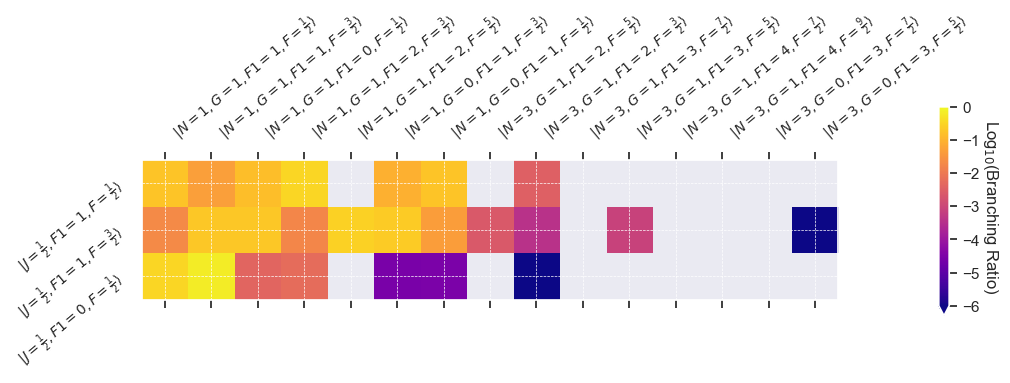

In [4]:
fig,ax = plt.subplots(figsize=(10,10),constrained_layout=True)
# ax.set_aspect('equal')
gidx = X0.select_q({'N':[1,3]},parity='-')
eidx = A0.select_q({'J':[1/2],'P':[1/2]},parity='+')

log=True
BR_plot = BR0.T
if log:
    BR_plot=np.log10(BR0)
    vmin = -6
    vmax = 0
else:
    vmin=0
    vmax = 1
#     log_BR = np.copy(BR0)
#     for i,val1 in enumerate(log_BR):
#         for j,val2 in enumerate(val1):
#             if val2 !=0:
#                 log_BR[i,j] = np.log10(val2)
#     BR_plot = log_BR
BR_plot = BR_plot[:,eidx][gidx,:].T
mat = ax.matshow(BR_plot,cmap=plt.get_cmap('plasma'),vmax = vmax, vmin = vmin)
x = np.arange(0,len(gidx))
y = np.arange(0,len(eidx))
ax.set_yticks(y)
ax.set_xticks(x)
x_labels = [X0.gen_state_str(i,basis='bBS',show_coeff=False,label_q=['N','G','F1','F'],round=4,single=True) for i in gidx]
y_labels = [A0.gen_state_str(i,round=4,single=True,show_coeff=False,label_q=['J','F1','F']) for i in eidx]
ax.set_yticklabels(y_labels, rotation=40, fontsize=12, ha='right')
ax.set_xticklabels(x_labels, rotation=40, fontsize=12,ha='left')
ax.tick_params(axis='both',labelsize=10,direction='out')
ax.grid(True,which='major',color='white',ls='--',linewidth=0.5)
ax.grid(False,which='minor')
(bot,top) = ax.get_ylim()
# ax.set_ylim(bot+0.5, top-0.5)
cbar = fig.colorbar(mat, ax=ax,fraction=0.015, pad=-0.05,extend='min')
cbar.set_label('Log$_{10}$(Branching Ratio)', rotation=270, labelpad=15, fontsize=12)
plt.show()
#ax.set_xlim(-0.5,x.size+0.5);

In [5]:
y_labels

['$\\,\\,|J=\\frac{1}{2},F1=1,F=\\frac{1}{2}\\rangle\\,$',
 '$\\,\\,|J=\\frac{1}{2},F1=1,F=\\frac{3}{2}\\rangle\\,$',
 '$\\,\\,|J=\\frac{1}{2},F1=0,F=\\frac{1}{2}\\rangle\\,$']

In [6]:
BR_=BR0[:,eidx][gidx,:]
BR_[:,-1]

array([0.3291722, 0.6607859, 0.0041312, 0.0058536, 0.       , 0.0000272,
       0.0000299, 0.       , 0.       , 0.       , 0.       , 0.       ,
       0.       , 0.       , 0.       ])

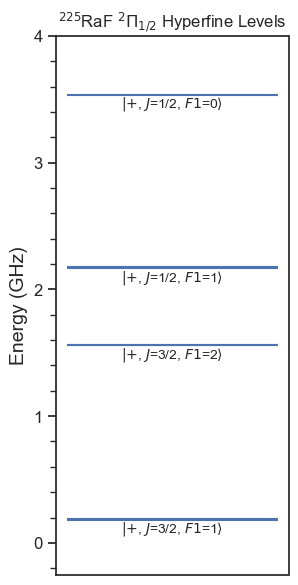

In [ ]:
ASO = 40471000
A0.display_levels(0,1e-8,pattern_q='J',
                  idx=A0.select_q({'J':[0.5,1.5],'P':[1/2]},parity='+'),label=True,
                  label_q=['J','F1'],parity=True,alt_label=False,figsize=(3,7),deltaE_label=500, )
plt.xlabel('')
plt.minorticks_on()
actual_ticks = np.arange(-7e3,-3e3+1e3,1e3)-ASO/2+16e3
plt.yticks(actual_ticks,labels=np.arange(0,5,1))
plt.xticks([])
# plt.ylim(-10e3,90e3)
plt.ylabel('Energy (GHz)')
plt.title(r'$^{225}$RaF ${}^2\Pi_{1/2}$ Hyperfine Levels',fontsize=12)
plt.show()

In [7]:
import copy

def select_dipole(dipole,TDM_func):
    if dipole == 'z':
        TDM = TDM_func(0)
    elif dipole == '+':
        TDM = TDM_func(1)
    elif dipole == '-':
        TDM = TDM_func(1)
    elif 'x' in dipole:
        TDMx = -1/np.sqrt(2)*(TDM_func(1)-TDM_func(-1))
        if dipole=='x':
            TDM=TDMx
        elif dipole=='x+z' or dipole=='z+x':
            TDM = 1/np.sqrt(2)*(abs(TDMx)+abs(TDM_func(0)))
    else:
        TDM = 1/np.sqrt(3)*(abs(TDM_func(-1))+abs(TDM_func(0))+abs(TDM_func(1)))
    return TDM

def lorentzian(f,f0,g,N):
    return N*(g/2)**2 /((f-f0)**2 + (g/2)**2)


def simulate_spectra(field_EB,state_g,state_e,g_idx,e_idx,ret_str =False,with_F=True,freq_array=None,diagonalize=False,T=4,origin = 0,P_adjust=False,square=True,pad=10,dipole='z',cm=True,thresh=1e-3,g=7.9/(29979.2458),dip=False,make_lorentzians=True,plot=True):
    E0, B0 = field_EB
    if diagonalize:
        G_evals,G_evecs = copy.deepcopy(state_g.eigensystem(E0,B0))
        E_evals,E_evecs = copy.deepcopy(state_e.eigensystem(E0,B0))
    else:
        G_evals,G_evecs = copy.deepcopy(state_g.evals0),copy.deepcopy(state_g.evecs0)
        E_evals,E_evecs = copy.deepcopy(state_e.evals0),copy.deepcopy(state_e.evecs0)
    TDM_func = partial(Calculate_TDMs,Ground=state_g,Excited=state_e,Ez=E0,Bz=B0,q=[-1,1])
    TDM_EB = select_dipole(dipole,TDM_func)
    if cm:
        E_evals/=29979.2458
        G_evals/=29979.2458
    E_evals+= origin
    dE_EB = np.subtract.outer(E_evals, G_evals)
    
    all_param = []
    flist = []
    TDMlist = []
    t_str_list = []
    for i in g_idx:
        vec_g = G_evecs[i,:]
        q_g = abs(vec_g).argmax()
        for j in e_idx:
            vec_e = E_evecs[j,:]
            q_e = abs(vec_e).argmax()
            Je,Me,Fe = [state_e.q_numbers[_q][q_e] for _q in ['J','M','F']]
            Pe = {1:'+',-1:'-'}[state_e.parities[j]]
            Ng,Jg,Mg,Fg = [state_g.q_numbers[_q][q_g] for _q in ['N','J','M','F']]
            Pg = {1:'+',-1:'-'}[state_g.parities[i]]
            if Me % 1 == 0:
                Me=int(Me)
                Mg = int(Mg)
#                 if N==1:
#                     boltz=1
#                 else:
#                     boltz = np.exp(-(0.352*(N*(N+1)-2)/T))
            if cm:
                boltz = np.exp(-G_evals[i]*1.439/T)
            else:
                boltz = np.exp(-4.799e-5*G_evals[i]/T)
            _TDM = TDM_EB[j,i]
            _dE = dE_EB[j,i]
            if _dE<0:
                continue
            if abs(_TDM) < thresh:
                continue
            flist.append(_dE)
            if square:
                _TDM = np.square(_TDM)
            _TDM*= boltz
            if Jg>Je and P_adjust:
                _TDM*=(2*Je+1)/(2*Jg+1)
            all_param.append([_dE,g,_TDM])
            TDMlist.append(_TDM)
            # with_F = True
            if ret_str:
                if with_F:
                    full_str = '(N={Ng}{Pg},J={Jg},F={Fg},M={Mg})->(J={Je}{Pe},F={Fe},M={Me})\nTDM={tdm}'.format(Je=Je,Fe=Fe,Me=Me,Pe=Pe,Ng=Ng,Jg=Jg,Fg=Fg,Mg=Mg,Pg=Pg,tdm=_TDM)
                else:
                    dJ = Je-Jg
                    PQR_J = {-2:'O',-1:'P', 0:'Q', 1:'R',2:'S'}[dJ]
                    dJN = Jg - Ng
                    dN = (Je-0.5) - Ng
                    PQR_N = {-2:'O',-1:'P', 0:'Q', 1:'R',2:'S'}[dN]
                    F12 = {0.5:'1',-0.5:'2'}[dJN]
                    full_str = []
                    pqr_str = r'$^{{{pqr_n}}} {{{pqr_j}}}_{{1{{{fi}}}}}({{{Ng}}}^{{{{{Pg}}}}})$'.format(pqr_n=PQR_N,pqr_j=PQR_J,fi=F12,Ng=Ng,Pg=Pg)
                    full_str.append(pqr_str)
                    qn_str = ['{Ng}, {Jg2}/2'.format(Ng=Ng,Jg2=int(Jg*2)),'{Je2}/2'.format(Je2=int(Je*2))]
                    full_str.extend(qn_str)
                    freq_str = ['{}'.format(np.round(_dE,5))]
                    full_str.extend(freq_str)
#                     '\t' + r'$N={{{Ng}}}^{{{{{Pg}}}}},J={{{Jg}}},M={{{Mg}}} \rightarrow J={{{Je}}}^{{{{{Pe}}}}},M={{{Me}}}$'.format(Je=Je,Me=Me,Pe=Pe,Ng=Ng,Jg=Jg,Mg=Mg,Pg=Pg)
                t_str_list.append(full_str)
    if flist==[]:
        flist.append(0)
        all_param.append([0,g,0])
        TDMlist.append(0)
    if make_lorentzians:
        if freq_array is None:
            fmin = min(flist)-pad*g
            fmax = max(flist)+pad*g
            n=int((fmax-fmin)/(g/20))
            freq = np.linspace(fmin,fmax,n)
        else:
            freq = freq_array
            n = len(freq_array)
        tot_lor = np.zeros(n)
        for param in all_param:
            tot_lor+=lorentzian(freq,*param)
        if dip:
            tot_lor*=-1
        if plot:
            plt.figure()
            plt.plot(freq,tot_lor)
        if ret_str:
            return flist,(freq,tot_lor),TDMlist,t_str_list
        else:
            return flist,(freq,tot_lor),TDMlist
    else:
        if ret_str:
            return flist,TDMlist,t_str_list
        else:
            return flist,TDMlist


def simulate_spectra_noM(field_EB,state_g,state_e,g_idx,e_idx,ret_str =False,with_F=True,freq_array=None,diagonalize=False,boltz_bool=True,T=4,origin = 0,P_adjust=False,pad=10,dipole='z',cm=True,thresh=1e-3,g=7.9/(29979.2458),dip=False,make_lorentzians=True,plot=True):
    E0, B0 = field_EB
    if diagonalize:
        G_evals,G_evecs = copy.deepcopy(state_g.eigensystem(E0,B0))
        E_evals,E_evecs = copy.deepcopy(state_e.eigensystem(E0,B0))
    else:
        G_evals,G_evecs = copy.deepcopy(state_g.evals0),copy.deepcopy(state_g.evecs0)
        E_evals,E_evecs = copy.deepcopy(state_e.evals0),copy.deepcopy(state_e.evecs0)
    BR_EB = branching_ratios(state_g,state_e,E0,B0).T
    if cm:
        E_evals/=29979.2458
        G_evals/=29979.2458
    E_evals+= origin
    dE_EB = np.subtract.outer(E_evals, G_evals)
    
    all_param = []
    flist = []
    BRlist = []
    t_str_list = []
    for i in g_idx:
        vec_g = G_evecs[i,:]
        q_g = abs(vec_g).argmax()
        for j in e_idx:
            vec_e = E_evecs[j,:]
            q_e = abs(vec_e).argmax()
            Je,Me,Fe = [state_e.q_numbers[_q][q_e] for _q in ['J','M','F']]
            Pe = {1:'+',-1:'-'}[state_e.parities[j]]
            Ng,Jg,Mg,Fg = [state_g.q_numbers[_q][q_g] for _q in ['N','J','M','F']]
            Pg = {1:'+',-1:'-'}[state_g.parities[i]]
            if Me % 1 == 0:
                Me=int(Me)
                Mg = int(Mg)
#                 if N==1:
#                     boltz=1
#                 else:
#                     boltz = np.exp(-(0.352*(N*(N+1)-2)/T))
            if cm:
                boltz = np.exp(-G_evals[i]*1.439/T)
            else:
                boltz = np.exp(-4.799e-5*G_evals[i]/T)
            _BR =BR_EB[j,i]
            _dE = dE_EB[j,i]
            if _dE<0:
                continue
            if abs(_BR) < thresh:
                continue
            flist.append(_dE)
            # if square:
            #     _TDM = np.square(_TDM)
            if boltz_bool:
                _BR*= boltz
            if Jg>Je and P_adjust:
                _BR*=(2*Je+1)/(2*Jg+1)
            all_param.append([_dE,g,_BR])
            BRlist.append(_BR)
            # with_F = True
            if ret_str:
                if with_F:
                    full_str = '(J={Jg},F={Fg})->(J={Je}{Pe},F={Fe})\nBR={br}'.format(Je=Je,Fe=Fe,Pe=Pe,Ng=Ng,Jg=Jg,Fg=Fg,Pg=Pg,br=_BR)
                    # full_str = '(N={Ng}{Pg},J={Jg},F={Fg})->(J={Je}{Pe},F={Fe})\nBR={br}'.format(Je=Je,Fe=Fe,Pe=Pe,Ng=Ng,Jg=Jg,Fg=Fg,Pg=Pg,br=_BR)
                else:
                    dJ = Je-Jg
                    PQR_J = {-2:'O',-1:'P', 0:'Q', 1:'R',2:'S'}[dJ]
                    dJN = Jg - Ng
                    dN = (Je-0.5) - Ng
                    PQR_N = {-2:'O',-1:'P', 0:'Q', 1:'R',2:'S'}[dN]
                    F12 = {0.5:'1',-0.5:'2'}[dJN]
                    full_str = []
                    pqr_str = r'$^{{{pqr_n}}} {{{pqr_j}}}_{{1{{{fi}}}}}({{{Ng}}}^{{{{{Pg}}}}})$'.format(pqr_n=PQR_N,pqr_j=PQR_J,fi=F12,Ng=Ng,Pg=Pg)
                    full_str.append(pqr_str)
                    qn_str = ['{Ng}, {Jg2}/2'.format(Ng=Ng,Jg2=int(Jg*2)),'{Je2}/2'.format(Je2=int(Je*2))]
                    full_str.extend(qn_str)
                    freq_str = ['{}'.format(np.round(_dE,5))]
                    full_str.extend(freq_str)
#                     '\t' + r'$N={{{Ng}}}^{{{{{Pg}}}}},J={{{Jg}}},M={{{Mg}}} \rightarrow J={{{Je}}}^{{{{{Pe}}}}},M={{{Me}}}$'.format(Je=Je,Me=Me,Pe=Pe,Ng=Ng,Jg=Jg,Mg=Mg,Pg=Pg)
                t_str_list.append(full_str)
    if flist==[]:
        flist.append(0)
        all_param.append([0,g,0])
        BRlist.append(0)
    if make_lorentzians:
        if freq_array is None:
            fmin = min(flist)-pad*g
            fmax = max(flist)+pad*g
            n=int((fmax-fmin)/(g/20))
            freq = np.linspace(fmin,fmax,n)
        else:
            freq = freq_array
            n = len(freq_array)
        tot_lor = np.zeros(n)
        for param in all_param:
            tot_lor+=lorentzian(freq,*param)
        if dip:
            tot_lor*=-1
        if plot:
            plt.figure()
            plt.plot(freq,tot_lor)
        if ret_str:
            return flist,(freq,tot_lor),BRlist,t_str_list
        else:
            return flist,(freq,tot_lor),BRlist
    else:
        if ret_str:
            return flist,BRlist,t_str_list
        else:
            return flist,BRlist

In [ ]:
N_g = np.arange(0,4)
N_e = np.arange(1,4)

In [ ]:
g = MoleculeLevels.initialize_state('YbOH','174','X000',N_g,M_values = 'none',I=[0,1/2],S=1/2,round=8,P_values=[1/2])
e = MoleculeLevels.initialize_state('YbOH','174','A000',N_e,M_values = 'none',I=[0,1/2],S=1/2,round=8,P_values=[1/2])
g.eigensystem(0,1e-3);
e.eigensystem(0,1e-3);
# gidx = g.select_q({'N':[0,1,2,3,4,5,7,8,9,10,11]})
# eidx = e.select_q({'J':[0.5,1.5,2.5,3.5,4.5,5.5,6.5,7.5,8.5,9.5,10.5,11.5]})

Cannot construct decoupled basis without M values
Cannot construct decoupled basis without M values


In [ ]:
g.parameters

{'mu_B': 1.399624494,
 'g_S': 2.0023,
 'g_L': 1,
 '2_e0c': 75346062800.0,
 'mu_N': 0.000762259323,
 'Be': 5755.56,
 'Gamma_SR': 175.38,
 'bF': 96.3,
 'c': 19,
 'muE': 1.96834092,
 'D': 0.004197094412}

In [ ]:
e.parameters

{'mu_B': 1.399624494,
 'g_S': 2.0023,
 'g_L': 1,
 '2_e0c': 75346062800.0,
 'mu_N': 0.000762259323,
 'Be': 5726.471605811175,
 'ASO': 0.0,
 'h1/2': 0,
 'a': 9.5,
 'bF': 0,
 'c': 0,
 'd': -9,
 'p+2q': -12312.770346461299,
 'q': 0,
 'D': 0.004197094412,
 'p2q_D': 0.005696056702,
 'g_lp': -0.724,
 'muE': 0.21646716,
 'Origin': 13284.618014811987}

In [ ]:
new_params=e.parameters
new_params['d']=-9
new_params['h1/2']=0
e.update_params(new_params)

Successfully converted eigenvectors from bBJ to aBJ


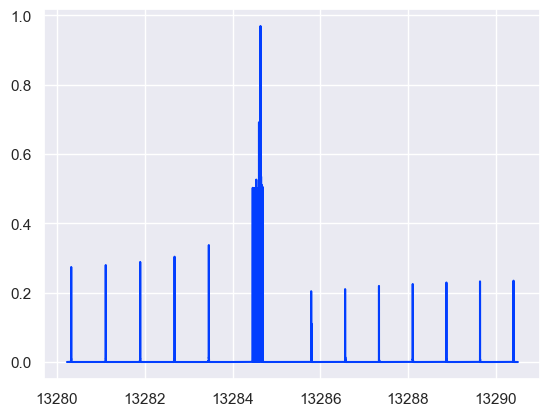

In [ ]:
gidx = g.select_q({'N':N_g.tolist()})
eidx = e.select_q({'J':(N_e-1/2).tolist()})
flist,(freq,tot_lor),BRlist,t_str_list = simulate_spectra_noM([0,0],g,e,gidx,eidx,ret_str =True,freq_array=None,boltz_bool=False,diagonalize=False,T=2,origin = e.parameters['Origin'],P_adjust=False,pad=300,dipole='all',cm=True,thresh=1e-5,g=6/(29979.2458),dip=False,make_lorentzians=True,plot=True)

0
(J=0.5,F=1.0)->(J=0.5+,F=0.0)
13284.636760623529
0.47628580873781834 

1
(J=0.5,F=1.0)->(J=0.5+,F=1.0)
13284.63677286468
0.48864217586472797 

2
(J=0.5,F=0.0)->(J=0.5+,F=1.0)
13284.635677092076
0.22382153909926855 

3
(J=1.5,F=1.0)->(J=0.5+,F=0.0)
13284.628478086752
0.5237141940322405 

4
(J=1.5,F=1.0)->(J=0.5+,F=1.0)
13284.628490327903
0.011357825079241558 

5
(J=1.5,F=2.0)->(J=0.5+,F=1.0)
13284.626711902538
0.2761709002925938 



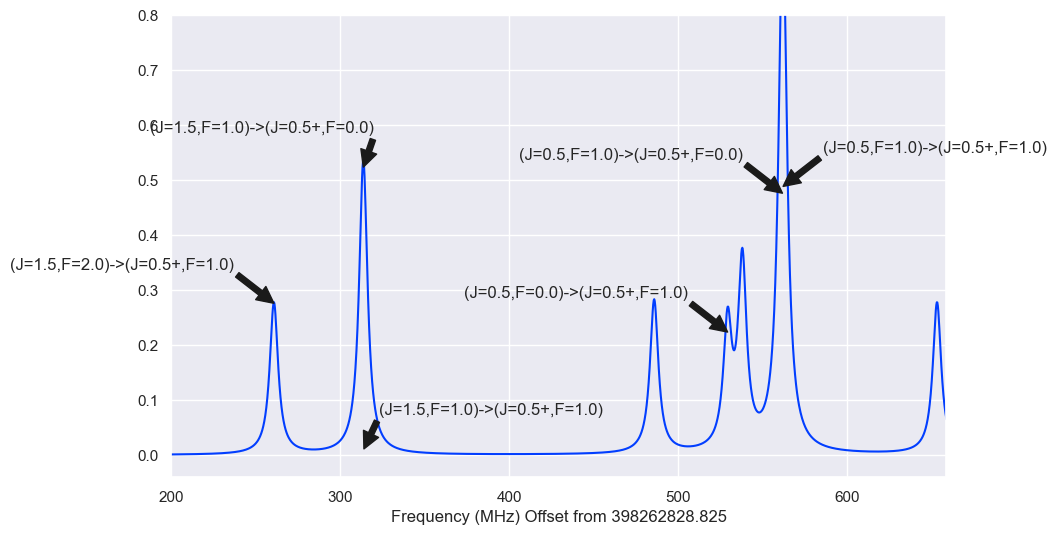

In [ ]:
c=29979.2458
origin = e.parameters['Origin']
plt.figure(figsize=(10,6))
MHz = lambda x:c*(x-origin)
fMHz = MHz(freq) 
plt.plot(fMHz,tot_lor)

#Wavenumbers of interest
plt.xlim(200,MHz(13284.64))
# plt.axvline(MHz(13284.63676),color='k',linestyle=':')
# plt.axvline(MHz(13284.63677),color='k',linestyle=':')
# plt.axvline(MHz(13284.63568),color='k',linestyle=':')
# plt.axvline(MHz(13284.62848),color='k',linestyle=':')
# plt.axvline(MHz(13284.62849),color='k',linestyle=':')
# plt.axvline(MHz(13284.62671),color='k',linestyle=':')
plt.ticklabel_format(useOffset=False)
plt.xlabel('Frequency (MHz) Offset from {}'.format(np.round(c*(origin),3)))
plt.ylim(-0.04,0.8)

i=0
side = [-3,3,-3,-2,2.5,-3]
lc_lines = []
for tstr,line in zip(t_str_list,flist):
    if 'J=0.5+,' in tstr:
        BR = tstr.split('\n')[-1].split('=')[-1]
        print(i)
        plt.annotate(tstr.split('\n')[0],xy=(MHz(line),float(BR)),ha='center',va='center',xytext=(MHz(line)+30*side[i],float(BR)+0.07),arrowprops={'color':'k'})
        i+=1
        print(tstr.split('\n')[0])
        print(line)
        print(BR,'\n')
        lc_lines.append(line)

In [ ]:
help(tstr.split)

Help on built-in function split:

split(sep=None, maxsplit=-1) method of builtins.str instance
    Return a list of the substrings in the string, using sep as the separator string.
    
      sep
        The separator used to split the string.
    
        When set to None (the default value), will split on any whitespace
        character (including \n \r \t \f and spaces) and will discard
        empty strings from the result.
      maxsplit
        Maximum number of splits (starting from the left).
        -1 (the default value) means no limit.
    
    Note, str.split() is mainly useful for data that has been intentionally
    delimited.  With natural text that includes punctuation, consider using
    the regular expression module.



In [ ]:
gM = MoleculeLevels.initialize_state('YbOH','174','X000',[0,1,2,3],M_values = 'all',I=[0,0],S=1/2,round=8,P_values=[1/2])
# eM.update_params(new_params)

In [ ]:
eM = MoleculeLevels.initialize_state('YbOH','174','A000',[1,2,3],M_values = 'all',I=[0,1/2],S=1/2,round=8,P_values=[1/2,3/2])
# eM.update_params(new_params)

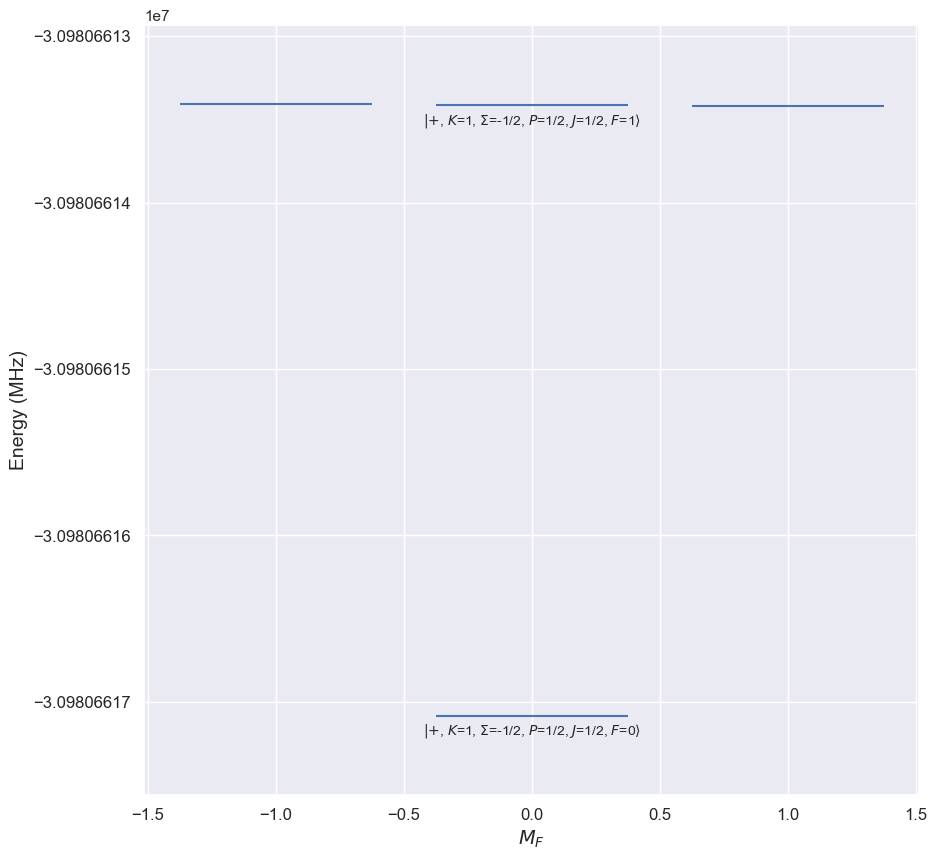

In [ ]:
eM.display_levels(0,1e-3,'F',idx=eM.select_q({'J':0.5},parity='+'),parity=True)
plt.ticklabel_format(useOffset=False)

In [ ]:
help(eM.gen_state_str)

Help on method gen_state_str in module Energy_Levels:

gen_state_str(vector_idx, evecs=None, basis=None, label_q=None, parity=False, single=False, thresh=0.01, show_coeff=True, new_line=False, round=None, frac='') method of Energy_Levels.MoleculeLevels instance



In [ ]:
eM.select_q({'J':1/2},parity='+')

array([12, 13, 14, 15])

In [ ]:
display(Latex(eM.gen_state_str(eM.select_q({'J':1/2,'M':0},parity='+')[0],basis='bBJ',label_q=['N','J','K'])))

<IPython.core.display.Latex object>

In [ ]:
for i in gM.select_q({'J':5/2,'M':0}):
    display(Latex(gM.gen_state_str(i,basis='aBJ',label_q=['J','Sigma'])))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [ ]:
for i in gM.select_q({'J':5/2,'M':0}):
    display(Latex(gM.gen_state_str(i,basis='bBJ',label_q=['N','J','K'])))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [ ]:


11882.96671 - 11882.59973

In [ ]:
eM.parameters

{'mu_B': 1.399624494,
 'g_S': 2.0023,
 'g_L': 1,
 '2_e0c': 75346062800.0,
 'mu_N': 0.000762259323,
 'Be': 5726.471605811175,
 'ASO': 0.0,
 'h1/2': 0,
 'a': 9.5,
 'bF': 0,
 'c': 0,
 'd': -9,
 'p+2q': -12312.770346461299,
 'q': 0,
 'D': 0.004197094412,
 'p2q_D': 0.005696056702,
 'g_lp': -0.724,
 'muE': 0.21646716,
 'Origin': 13284.618014811987}

In [ ]:
e.evals0

array([  -429.99947,   -429.66492,  10591.65073,  10593.92092,
        11879.77071,  11892.09973,  33067.07307,  33070.07529,
        35215.81962,  35223.15139,  66995.21793,  66998.58459,
        70004.378  ,  70010.6339 , 112375.62328, 112379.21036,
       116245.30347, 116251.08023, 169207.81847, 169211.55373,
       173938.26086, 173943.76505, 237491.25332, 237495.09518,
       243082.79304, 243088.12098, 317225.28398, 317229.20627,
       323678.3351 , 323683.53958, 408409.1688 , 408413.15417,
       415724.21846, 415729.33161, 519219.6717 , 519224.71529])

In [ ]:
lc_MHz = MHz(np.array(sorted(lc_lines)))
lc_MHz-=lc_MHz[0]
lc_MHz= np.delete(lc_MHz,2)
print(lc_MHz)
print(lc_MHz[1:]-lc_MHz[:-1])

[  0.       52.94887 268.76962 301.25308 301.62006]
[ 52.94887 215.82075  32.48346   0.36698]


In [ ]:
tstr.split('\n')[1].split('=')[-1]

'0.23333310486192418'

In [ ]:
display(Latex(e.gen_state_str(5, thresh=1e-5,label_q=['P','J','F'])))

<IPython.core.display.Latex object>

In [ ]:
display(Latex(e.gen_state_str(4, thresh=1e-5,label_q=['P','J','F'])))

<IPython.core.display.Latex object>

In [ ]:
for tstr,line in zip(t_str_list,flist):
    if 'J=0.5+,' in tstr:
        print(tstr)
        print(line,'\n')

(J=0.5,F=1.0)->(J=0.5+,F=0.0)
BR=0.4762857413808356
13284.636760684702 

(J=0.5,F=1.0)->(J=0.5+,F=1.0)
BR=0.49014233154315795
13284.636772932992 

(J=0.5,F=0.0)->(J=0.5+,F=1.0)
BR=0.22054759039660846
13284.635677160388 

(J=1.5,F=1.0)->(J=0.5+,F=0.0)
BR=0.5237141199678714
13284.628478147924 

(J=1.5,F=1.0)->(J=0.5+,F=1.0)
BR=0.009857643703166163
13284.628490396215 

(J=1.5,F=2.0)->(J=0.5+,F=1.0)
BR=0.27944364429418567
13284.62671197085 



In [ ]:
leakage = np.array([2.43e-5,3.82e-6,9.16e-7,1.09e-6,4.20e-6,2.58e-5])
d_vals = np.array([-50,-20,-10,10,20,50])

In [ ]:
for tstr,line in zip(t_str_list,flist):
    if line>13284.62 and line<13284.65:
        print(tstr)
        print(line,'\n')

(J=0.5,F=1.0)->(J=0.5+,F=0.0)
BR=0.4762857413808356
13284.636760684702 

(J=0.5,F=1.0)->(J=0.5+,F=1.0)
BR=0.49014233154315795
13284.636772932992 

(J=0.5,F=0.0)->(J=0.5+,F=1.0)
BR=0.22054759039660846
13284.635677160388 

(J=1.5,F=1.0)->(J=0.5+,F=0.0)
BR=0.5237141199678714
13284.628478147924 

(J=1.5,F=1.0)->(J=0.5+,F=1.0)
BR=0.009857643703166163
13284.628490396215 

(J=1.5,F=2.0)->(J=0.5+,F=1.0)
BR=0.27944364429418567
13284.62671197085 

(J=1.5,F=1.0)->(J=1.5-,F=1.0)
BR=0.4444667943049587
13284.648895178447 

(J=1.5,F=1.0)->(J=1.5-,F=2.0)
BR=0.05266187409437113
13284.648989304507 

(J=2.5,F=2.0)->(J=1.5-,F=1.0)
BR=0.33428624635846305
13284.63586280038 

(J=2.5,F=2.0)->(J=1.5-,F=2.0)
BR=0.0034919189722387644
13284.63595692644 

(J=2.5,F=3.0)->(J=1.5-,F=2.0)
BR=0.2806455443733192
13284.634288766474 

(J=3.5,F=3.0)->(J=2.5+,F=2.0)
BR=0.3000902339673417
13284.64140868775 

(J=3.5,F=3.0)->(J=2.5+,F=3.0)
BR=0.0017738116233672904
13284.641526442852 

(J=3.5,F=4.0)->(J=2.5+,F=3.0)
BR=0.2758459

In [ ]:
0.063+0.063+0.084

0.21000000000000002

In [ ]:
41.7226-41.0988

0.6238000000000028

In [ ]:
sorted(flist)

[13280.286577821755,
 13280.323061727011,
 13280.323261785541,
 13280.324492495156,
 13281.079478239526,
 13281.110105201855,
 13281.110314339261,
 13281.111522675017,
 13281.870467821025,
 13281.895235147493,
 13281.895460289546,
 13281.896632976004,
 13282.659543846641,
 13282.678447104825,
 13282.678708389396,
 13282.679812811251,
 13283.446707301853,
 13283.45973967992,
 13283.46017332374,
 13283.461042315625,
 13284.45842431129,
 13284.458614408952,
 13284.45999067302,
 13284.460180770682,
 13284.487352398977,
 13284.487546596667,
 13284.488930481168,
 13284.489124678857,
 13284.496664675939,
 13284.497905346421,
 13284.498095444083,
 13284.514332672294,
 13284.514532730824,
 13284.515927581235,
 13284.516127639765,
 13284.519751641186,
 13284.520974916659,
 13284.521169114349,
 13284.53936564958,
 13284.539574786986,
 13284.540894966232,
 13284.540986829732,
 13284.541195967138,
 13284.542092736214,
 13284.542292794744,
 13284.560099225322,
 13284.561255794342,
 13284.56146493174